# imports

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import torch

# Load Data

In [43]:
from datasets import load_dataset
dataset=load_dataset("stanfordnlp/imdb")

In [44]:
dataset


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

# inspect dataset

In [45]:
dataset.shape

{'train': (25000, 2), 'test': (25000, 2), 'unsupervised': (50000, 2)}

We have got 25000 training and 25000 test examples.

In [46]:
dataset['train'][0]

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

Each example has 2 parts, text and label.

Take train and test dataset into pandas for easier eda

In [47]:
train_df=dataset['train'].to_pandas()
test_df=dataset['test'].to_pandas()

### Basic infos

In [48]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    25000 non-null  str  
 1   label   25000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 32.0 MB


In [49]:
train_df.shape

(25000, 2)

In [50]:
train_df.columns

Index(['text', 'label'], dtype='str')

- info() shows column names, data types, and missing values.
- shape returns (rows, columns).
- columns lists every feature in the dataset.

In [51]:
train_df.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


# Inspect One Sample

In [52]:
sample=train_df.iloc[0] # take the first example
print("Review: \n")
print(sample['text'])
print()
print(f"Label: {sample['label']}")

Review: 

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

# Understand the Labels

In [53]:
train_df['label'].value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

Checking 1 (+ve) & 1 (-ve) example

In [54]:
print("Negative Example: \n")
print(train_df[train_df['label']==0]['text'].iloc[0])

Negative Example: 

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few 

In [55]:
print("Positive Example: \n")
print(train_df[train_df['label']==1]['text'].iloc[0])

Positive Example: 

Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emotionally involved with a woman he doesn't really understand, and whose naivety is all the more striking in contrast with the natives.<br /><br />But I'd have to say that The Third Man has a more well-crafted storyline. Zentropa is a bit disjointed in this respect. Perhaps this is intentional: it is presented as a dream/nightmare, and making it too coherent would spoil the effect. <br /><br />This movie is unrelentingly grim--"noir" in more than one sense; one never sees the sun shine. Grim, but intriguing, and frightening.


# Missing Values

In [56]:
train_df.isnull().sum()

text     0
label    0
dtype: int64

No null vals, we don't have to handle any.

# Duplicates

In [57]:
duplicates=train_df.duplicated().sum()
print(f"Duplicates: {duplicates}")

Duplicates: 96


We have 96 dupliates.

# Class Balance

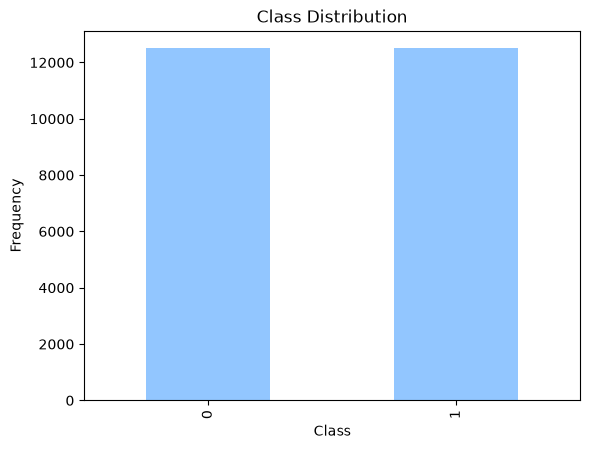

In [58]:
train_df['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.show()

We have equal number of +ve and -ve

# Character Length

In [59]:
train_df['char_length']=train_df['text'].str.len()
train_df['char_length'].describe()

count    25000.00000
mean      1325.06964
std       1003.13367
min         52.00000
25%        702.00000
50%        979.00000
75%       1614.00000
max      13704.00000
Name: char_length, dtype: float64

Counts every character.

Useful because BERT has a maximum input length of 512 tokens.

The average review contains approximately 1,325 characters, although review lengths vary considerably, ranging from 52 to 13,704 characters.

# Character Length Histogram

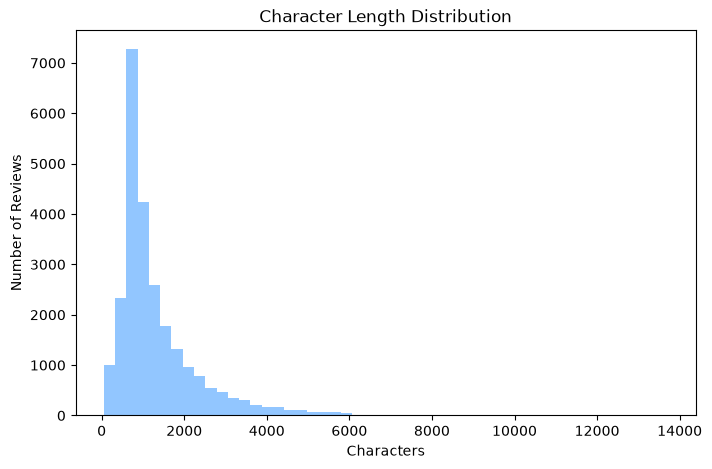

In [60]:
plt.figure(figsize=(8,5))

plt.hist(train_df['char_length'], bins=50)

plt.title("Character Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Number of Reviews")

plt.show()

# Word Length

In [61]:
train_df['word_length']=train_df['text'].str.split().str.len()
train_df['word_length'].describe()

count    25000.000000
mean       233.787200
std        173.733032
min         10.000000
25%        127.000000
50%        174.000000
75%        284.000000
max       2470.000000
Name: word_length, dtype: float64

* The average IMDB review contains approximately 234 words.
* Review lengths vary considerably, ranging from only 10 words to 2,470 words.
* The high standard deviation indicates that review lengths are highly variable.
* Most reviews (75%) contain fewer than 284 words, while a small number are exceptionally long.

BERT has a maximum sequence length of 512 tokens, not words. Since some reviews are much longer than this limit, they will need to be truncated during tokenization.

# Word Length Histogram

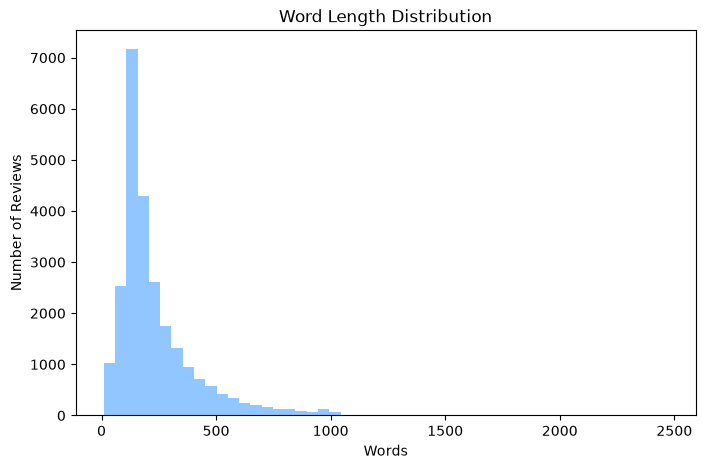

In [62]:
plt.figure(figsize=(8,5))

plt.hist(train_df['word_length'], bins=50)

plt.title("Word Length Distribution")
plt.xlabel("Words")
plt.ylabel("Number of Reviews")

plt.show()

# Noise Scan

Print random reviews.

In [63]:
train_df.sample(5, random_state=20)[['label', "text"]]

,label,text
8879,0,"Dark Rising is your typical bad, obviously qui..."
12093,0,I rented this shortly after renting Ben Stein'...
18594,1,This movie is horrible- in a 'so bad it's good...
18491,1,"by Dane Youssef <br /><br />""Coonskin"" is film..."
5764,0,This movie contains no humor for anyone who ha...


We have reviews containing HTML tags!

# Find Reviews Containing HTML

In [70]:
html_reviews=train_df[train_df['text'].str.contains("<br />", regex=False)]
print(f"reviews  containing HTML : {len(html_reviews)}")
html_reviews.head()

reviews  containing HTML : 14665


,text,label,char_length,word_length
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,1640,288
2,If only to avoid making this type of film in t...,0,528,93
3,This film was probably inspired by Godard's Ma...,0,706,118
4,"Oh, brother...after hearing about this ridicul...",0,1814,311
5,I would put this at the top of my list of film...,0,661,123


Approximately 58.7% of all training reviews contain HTML line-break tags `(<br />)`.

We'll remove these during preprocessing.

# Vocabulary Size

In [65]:
from collections import  Counter
counter=Counter()

for review in train_df['text']:
    counter.update(review.lower().split())
print(f"Vocabulary Size: {len(counter)}")

Vocabulary Size: 251637


Counts every unique word.

Gives an idea of the dataset's vocabulary diversity.

The training set contains over 250,000 unique words.

# Top 20 Most Common Words

In [66]:
counter.most_common(20)

[('the', 322198),
 ('a', 159953),
 ('and', 158572),
 ('of', 144462),
 ('to', 133967),
 ('is', 104171),
 ('in', 90527),
 ('i', 70480),
 ('this', 69714),
 ('that', 66292),
 ('it', 65505),
 ('/><br', 50935),
 ('was', 47024),
 ('as', 45102),
 ('for', 42843),
 ('with', 42729),
 ('but', 39764),
 ('on', 31619),
 ('movie', 30887),
 ('his', 29059)]

Shows the most frequent words.
You'll notice many common words ("the", "and", "of"), called stop words.
Since you're using BERT, you generally do not remove stop words because the model learns from sentence structure.

# Does Length Correlate with Sentiment

In [67]:
train_df.groupby('label')['word_length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,12500.0,230.86784,166.663126,10.0,128.0,174.0,278.0,1522.0
1,12500.0,236.70656,180.485743,12.0,125.0,174.0,291.0,2470.0


Compares statistics like mean, median, min, and max for each sentiment class.

If positive and negative reviews have very similar lengths, review length alone is unlikely to be a useful predictor.

The average review length is very similar for both sentiment classes.

Negative reviews average 230.9 words.
Positive reviews average 236.7 words.
Both classes have the same median length (174 words).

The difference in mean review length is only about 6 words, which is very small compared to an average review length of around 234 words.

This suggests that review length alone is not a useful indicator of sentiment. Instead of relying on whether a review is long or short, the model must learn the semantic meaning and context of the words used in the review to correctly classify its sentiment.


# Final Summary

In [68]:
print(f"Training samples : {len(train_df)}")
print(f"Testing samples  : {len(test_df)}")
print(f"Vocabulary size  : {len(counter):,}")
print(f"Duplicate rows   : {duplicates}")
print(f"Missing values   : {train_df.isnull().sum().sum()}")
print(f"Average words    : {train_df['word_length'].mean():.2f}")
print(f"Average chars    : {train_df['char_length'].mean():.2f}")

Training samples : 25000
Testing samples  : 25000
Vocabulary size  : 251,637
Duplicate rows   : 96
Missing values   : 0
Average words    : 233.79
Average chars    : 1325.07


The IMDB dataset is well-suited for binary sentiment classification. It contains 25,000 balanced training examples and 25,000 balanced test examples with no missing values. A small number of duplicate reviews (96) were identified but are unlikely to significantly impact model performance.

The dataset contains a rich vocabulary of approximately 251,000 unique words, reflecting diverse writing styles and expressions. Around 59% of reviews contain HTML line-break tags `(<br />)`, indicating that basic text cleaning will be necessary before tokenization.

Review lengths vary considerably, with an average of approximately 234 words. Although some reviews exceed BERT's maximum input length and will require truncation, most reviews fall well within a manageable range. Furthermore, positive and negative reviews exhibit nearly identical length distributions, suggesting that sentiment cannot be inferred from review length alone. Consequently, the classification model must learn semantic and contextual information rather than relying on superficial characteristics such as text length.